# LightGBM Baseline (Optimal Features) - PS-S06E08

This notebook implements a LightGBM baseline for **Playground Series – Season 6, Episode 8: Predicting Smartphone Addiction**.

We employ Stratified 5-Fold cross-validation, multi-seed training, and hyperparameter tuning with an SQLite-backed Optuna database.

**Key diagnostic**: Based on feature engineering CV tests, LightGBM benefits from the full set of 69 engineered features. RFE has been eliminated.

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path

# --- Third-party
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from ps_s06e08_experiment_setup import ExperimentSetup
from ps_s06e08_feature_engineering import FeatureFactory
from ps_s06e08_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
setup = ExperimentSetup(
    model_name='LightGBM',
    use_gpu=False,  # Run on CPU to avoid GPU split assertions
    perform_rfe=False,
    perform_optuna_tuning=True
)

seed = setup.set_seeds()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'addicted_label'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Datasets

In [3]:
training_df = setup.read_dataset('training')
train_ids = training_df['id'].copy()

test_df = setup.read_dataset('test')
test_ids = test_df['id'].copy()

TRAINING DATASET

   id    age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   0 24.000                      NaN               1.830         1.590   
1   1 19.000                    5.970               1.080           NaN   
2   2 18.000                    5.090                 NaN           NaN   
3   3 21.000                    6.420               1.260         1.420   
4   4 26.000                   11.200               1.870         2.810   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0             2.110        7.460                122.000             38.000   
1             3.030        8.220                 76.000             19.000   
2               NaN        6.250                134.000             60.000   
3             3.360        8.850                112.000             94.000   
4             1.950        5.250                    NaN                NaN   

   weekend_screen_time  gender stress_level academic_work_impa

## 3. Feature Engineering

In [4]:
fe_strategies = [
    'encoding',
    'screen_time_ratios',
    'sleep_stress',
    'risk_score',
    'missing_flags',
    'quantile_binning',
]

factory = FeatureFactory(
    strategies=fe_strategies,
    impute_strategy='median_mode',
    target=TARGET,
    verbose=True
)

y = training_df[TARGET].copy()

X = factory.fit_transform(training_df)
X_test = factory.transform(test_df)

print(f"Train features shape: {X.shape}")
print(f"Test features shape: {X_test.shape}")

  -> Fitting DataFrame...
Applying FeatureFactory with strategies: encoding, screen_time_ratios, sleep_stress, risk_score, missing_flags, quantile_binning
  -> Imputing missing values using learned medians and modes...
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding screen time ratio features...
  -> Adding sleep_stress interaction features...
  -> Adding lifestyle risk score features...
  -> Adding quantile-binned features...
Applying FeatureFactory with strategies: encoding, screen_time_ratios, sleep_stress, risk_score, missing_flags, quantile_binning
  -> Imputing missing values using learned medians and modes...
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding screen time ratio features...
  -> Adding sleep_stress interaction features...
  -> Adding lifestyle risk score features...
  -> Adding quantile-binned features...
Train features shape: (691369, 51)
Test features shape: (296302, 51)


## 4. SQLite-Backed Optuna Optimization

Tunes model hyperparameters over a 5-fold CV split, caching trials dynamically in an SQLite database.

In [5]:
skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
fold_cache = []
for tr_idx, val_idx in skf_cv.split(X, y):
    fold_cache.append((tr_idx, val_idx))

def objective(trial):
    params = {
        "n_estimators": 5000,
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 0.010, 0.035, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 64, 160),
        "max_depth": -1,
        "min_child_samples": trial.suggest_int("min_child_samples", 30, 120),
        "subsample": trial.suggest_float("subsample", 0.75, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 4),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.35, 0.60),
        "reg_alpha": trial.suggest_float("reg_alpha", 1.0, 25.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 20.0, log=True),
        "random_state": seed,
        "n_jobs": -1,
        "verbosity": -1
    }
    
    oof_preds = np.full(len(y), -1.0, dtype=float)
    
    for fold, (tr_idx, val_idx) in enumerate(fold_cache):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(150, verbose=False)]
        )
        
        preds = model.predict_proba(X_val)[:, 1]
        oof_preds[val_idx] = preds
            
    filled_mask = oof_preds >= 0
    return roc_auc_score(y[filled_mask], oof_preds[filled_mask])

In [6]:
optuna_filename = "optuna_params_lgb.json"
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning():
    print("Starting LightGBM SQLite Optuna Optimization v8 (focused search space)...")
    
    pruner = optuna.pruners.NopPruner()
    
    study = optuna.create_study(
        storage="sqlite:///lgbm_study.db",
        load_if_exists=True,
        direction="maximize",
        study_name="lgbm_predict_smartphone_addiction_optuna_v8",
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=seed,
            n_startup_trials=5,
            multivariate=True
        )
    )
    
    # Enqueue previous best parameters if available
    if best_params and len(best_params) > 0:
        valid_params = {k: v for k, v in best_params.items() if k in ["learning_rate", "num_leaves", "min_child_samples", "subsample", "subsample_freq", "colsample_bytree", "reg_alpha", "reg_lambda"]}
        study.enqueue_trial(valid_params)
        print("Enqueued previous best parameters into Optuna study.")
    
    study.optimize(objective, n_trials=50, timeout=7200, show_progress_bar=True)
    best_params = study.best_params
    print(f'Best score: {study.best_value:.6f}')
    print("Best params found:", best_params)
    setup.save_optuna_params(optuna_filename, best_params)
    setup.upload_artifact(optuna_filename)

else:
    print("Using loaded parameters:", best_params)

Loaded 8 parameters from optuna_params_lgb.json
Starting LightGBM SQLite Optuna Optimization v8 (focused search space)...


[I 2026-08-31 12:59:15,868] Using an existing study with name 'lgbm_predict_smartphone_addiction_optuna_v8' instead of creating a new one.


Enqueued previous best parameters into Optuna study.


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-31 14:22:33,693] Trial 11 finished with value: 0.9640894460437437 and parameters: {'learning_rate': 0.0146628157721584, 'num_leaves': 74, 'min_child_samples': 74, 'subsample': 0.9495214664088015, 'subsample_freq': 4, 'colsample_bytree': 0.3503737314764472, 'reg_alpha': 6.856603656916008, 'reg_lambda': 1.1906399364899962}. Best is trial 11 with value: 0.9640894460437437.
[I 2026-08-31 17:09:20,035] Trial 12 finished with value: 0.963914402216033 and parameters: {'learning_rate': 0.012439769227426378, 'num_leaves': 78, 'min_child_samples': 90, 'subsample': 0.8918244180756106, 'subsample_freq': 2, 'colsample_bytree': 0.3820647865139504, 'reg_alpha': 7.79126809540826, 'reg_lambda': 6.380405467345084}. Best is trial 11 with value: 0.9640894460437437.
Best score: 0.964089
Best params found: {'learning_rate': 0.0146628157721584, 'num_leaves': 74, 'min_child_samples': 74, 'subsample': 0.9495214664088015, 'subsample_freq': 4, 'colsample_bytree': 0.3503737314764472, 'reg_alpha': 6.856

...

Upload successful: optuna_params_catboost.json (246B)
Starting upload for file optuna_params_xgb.json


100%|██████████| 282/282 [00:00<00:00, 470B/s]


Upload successful: optuna_params_xgb.json (282B)
Starting upload for file selected_features_xgb.json


100%|██████████| 1.11k/1.11k [00:00<00:00, 2.37kB/s]


Upload successful: selected_features_xgb.json (1KB)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/stephentarter/ps-s06e08-artifacts
Kaggle artifacts dataset upload completed successfully!


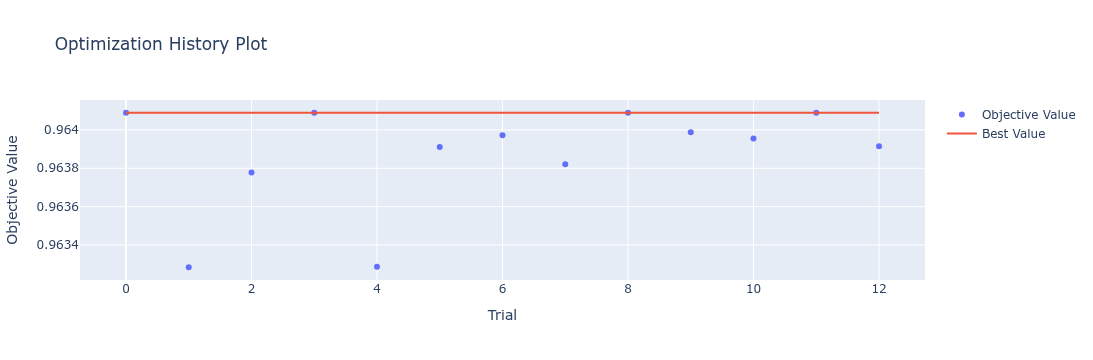

In [7]:
try:
    fig = optuna.visualization.plot_optimization_history(study)
    fig.show()
except NameError:
    print("Optuna wasn't run")

## 5. Model Training & Multi-Seed Blending

Trains the final seed-averaged models on the optimal engineered features.

In [8]:
seeds = setup.seed()

# Track multi-class style probabilities: column 0 = prob(0), column 1 = prob(1)
oof_probs = np.zeros((len(X), 2))
test_probs = np.zeros((len(X_test), 2))
filled_mask = np.zeros(len(X), dtype=bool)

models = []
eval_results = []

for s_idx, current_seed in enumerate(seeds):
    print(f"\n================ SEED RUN {s_idx + 1}/{len(seeds)}: seed={current_seed} ================")
    
    lgb_params = {
        **best_params,
        'n_estimators': 4000,
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'random_state': current_seed,
        'n_jobs': -1,  # Multi-threaded CPU execution
        'verbosity': -1
    }
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=current_seed)
    
    oof_probs_seed = np.zeros((len(X), 2))
    test_probs_seed = np.zeros((len(X_test), 2))
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        model = lgb.LGBMClassifier(**lgb_params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_tr, y_tr), (X_val, y_val)],
            eval_metric='auc',
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(period=200)
            ]
        )
        
        # Predict probabilities
        val_probs = model.predict_proba(X_val)
        oof_probs_seed[val_idx] = val_probs
        filled_mask[val_idx] = True
        
        test_probs_seed += model.predict_proba(X_test) / 5.0
        
        fold_score = roc_auc_score(y_val, val_probs[:, 1])
        n_trees = model.booster_.num_trees()
        print(f"  Fold {fold+1} ROC AUC: {fold_score:.6f} (trees={n_trees})")
        
        models.append(model)
        eval_results.append(model.evals_result_)
        
    seed_score = roc_auc_score(y, oof_probs_seed[:, 1])
    print(f"--- Seed {current_seed} CV ROC AUC: {seed_score:.6f} ---")
    
    oof_probs += oof_probs_seed / len(seeds)
    test_probs += test_probs_seed / len(seeds)

overall_score = roc_auc_score(y[filled_mask], oof_probs[filled_mask, 1])
print("\n" + "="*60)
print(f"Seed-Averaged CV ROC AUC: {overall_score:.6f}")
print("="*60)


================ SEED RUN 1/5: seed=10301 ================
[200]	training's auc: 0.94392	valid_1's auc: 0.942012
[400]	training's auc: 0.956236	valid_1's auc: 0.954118
[600]	training's auc: 0.960728	valid_1's auc: 0.958313
[800]	training's auc: 0.96312	valid_1's auc: 0.960302
[1000]	training's auc: 0.96466	valid_1's auc: 0.961377
[1200]	training's auc: 0.965737	valid_1's auc: 0.96196
[1400]	training's auc: 0.966601	valid_1's auc: 0.962284
[1600]	training's auc: 0.967351	valid_1's auc: 0.96253
[1800]	training's auc: 0.968038	valid_1's auc: 0.962702
[2000]	training's auc: 0.968676	valid_1's auc: 0.962844
[2200]	training's auc: 0.969282	valid_1's auc: 0.962937
[2400]	training's auc: 0.969865	valid_1's auc: 0.963036
[2600]	training's auc: 0.970427	valid_1's auc: 0.963117
[2800]	training's auc: 0.970942	valid_1's auc: 0.963174
[3000]	training's auc: 0.971456	valid_1's auc: 0.96324
[3200]	training's auc: 0.971948	valid_1's auc: 0.963267
[3400]	training's auc: 0.972425	valid_1's auc: 0.96329

## 6. Performance Visualization

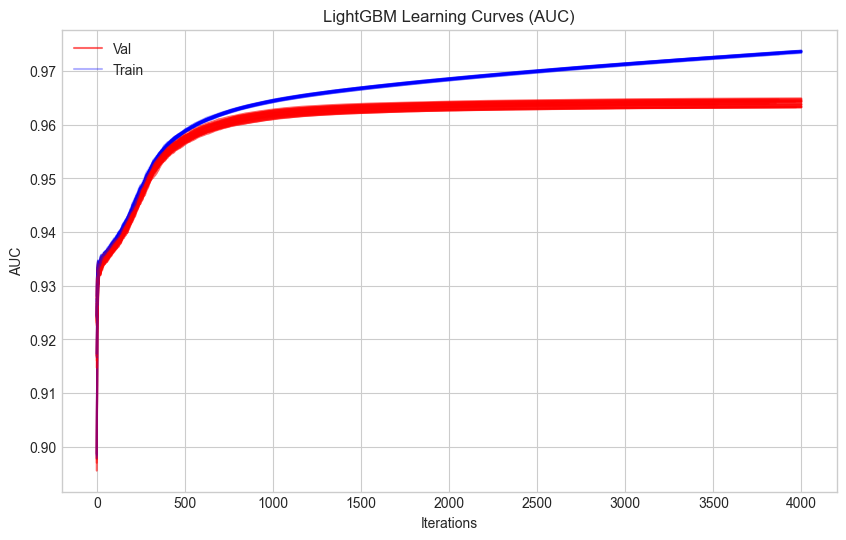

In [9]:
mviz = ModelVisualizer(model_name='LightGBM')

# Map learning metrics to ModelVisualizer expectations
adjusted_evals = []
for res in eval_results:
    adjusted_evals.append({
        'validation_0': res['valid_1'],
        'validation_1': res['training']
    })

mviz.plot_learning_curves(adjusted_evals, metric='auc')

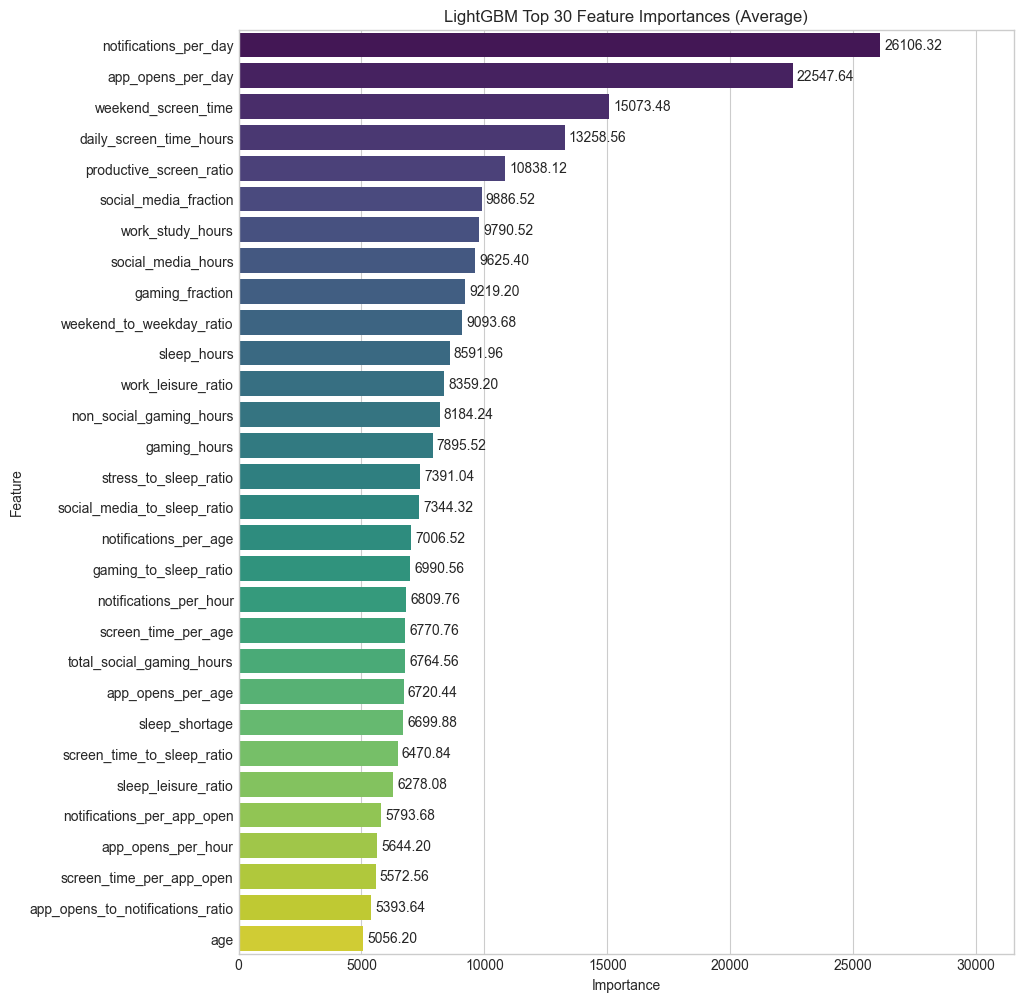

In [10]:
mviz.plot_feature_importance(models, show_values=True)

<Figure size 800x600 with 0 Axes>

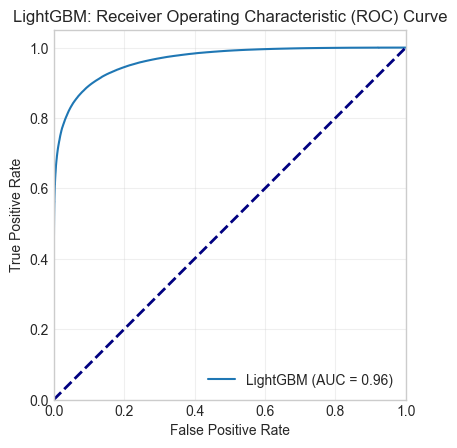

In [11]:
mviz.plot_roc_curve(y_true=y[filled_mask], y_score=oof_probs[filled_mask, 1])

Confusion matrix, without normalization


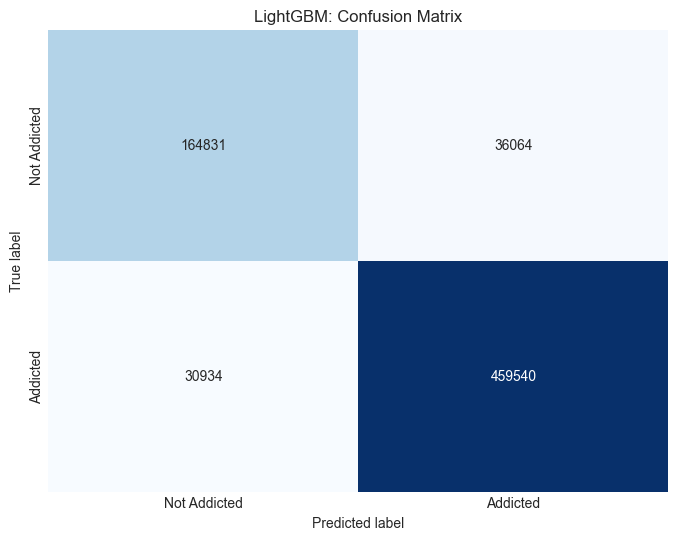

In [12]:
y_pred_class = (oof_probs[:, 1] > 0.5).astype(int)
mviz.plot_confusion_matrix(
    y_true=y[filled_mask],
    y_pred=y_pred_class[filled_mask],
    classes=['Not Addicted', 'Addicted']
)

## 7. Export Submission & Predictions

In [13]:
submission_df = setup.read_dataset('submission')
submission_df['addicted_label'] = test_probs[:, 1]
submission_df.to_csv('submission.csv', index=False)
print("Saved submission.csv successfully!")

Saved submission.csv successfully!


In [14]:
setup.save_probabilities('lgb', oof_probs, train_ids, y, filled_mask, test_probs, test_ids)

Saved for ensembling:
 - predictions/lgb_oof_probs.csv
 - predictions/lgb_test_probs.csv
